## Import

In [25]:
import warnings
from category_encoders import MEstimateEncoder
from IPython.display import display
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import mutual_info_regression
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from xgboost import XGBRegressor
from pathlib import Path
warnings.filterwarnings("ignore")
from sklearn.preprocessing import StandardScaler

## Import Data 

In [ ]:


csv_candidates = [
    Path("student_dataset/student_failure/train.csv"),
    Path("../student_dataset/student_failure/train.csv"),
]

for csv_path in csv_candidates:
    if csv_path.exists():
        data = pd.read_csv(csv_path)
        break


# Afficher les premières lignes du dataset
X = data.drop(["score_examen", "id"], axis=1)
y = data.score_examen
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, test_size=0.2, random_state=0
)

In [15]:
X.head()
y_train.head()

618985    58.76
617988    28.30
228055    38.15
532270    86.39
219639    79.60
Name: score_examen, dtype: float64

## Data Exploration and Analysis

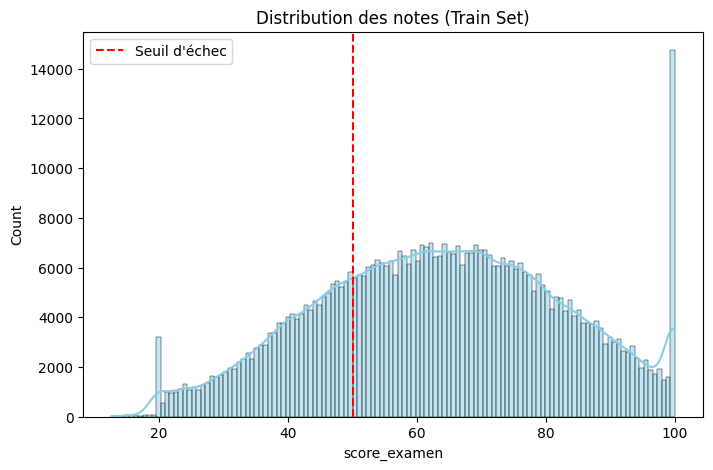

In [20]:
plt.figure(figsize=(8, 5))
sns.histplot(y_train, kde=True, color='skyblue')
plt.axvline(50, color='red', linestyle='--', label="Seuil d'échec")
plt.title("Distribution des notes (Train Set)")
plt.legend()
plt.savefig("../Graph/score_distribution.png")
plt.show()


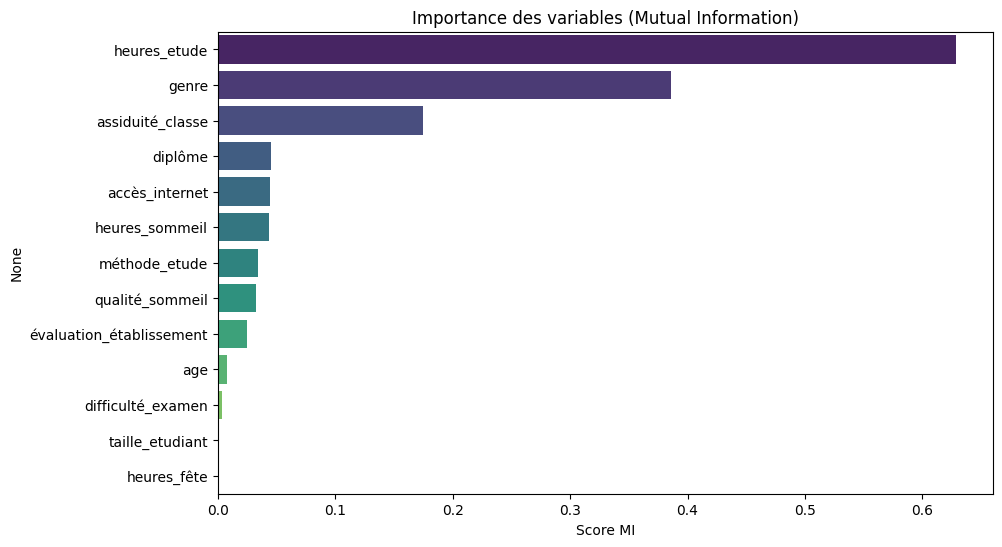

In [22]:
X_mi = X_train.copy()

for col in X_mi.select_dtypes(include='number').columns:
    X_mi[col] = X_mi[col].fillna(X_mi[col].median())
 
for col in X_mi.select_dtypes(include='object').columns:
    X_mi[col], _ = X_mi[col].factorize()

discrete_features = X_mi.dtypes == int

mi_scores = mutual_info_regression(X_mi, y_train, discrete_features=discrete_features, random_state=0)
mi_scores_series = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=mi_scores_series.values, y=mi_scores_series.index, palette='viridis')
plt.title("Importance des variables (Mutual Information)")
plt.xlabel("Score MI")
plt.savefig("../Graph/mi_scores.png")
plt.show()


In [23]:
print("Mutual Information Scores:", mi_scores_series)

Mutual Information Scores: heures_etude                0.628489
genre                       0.385986
assiduité_classe            0.174912
diplôme                     0.044910
accès_internet              0.044489
heures_sommeil              0.043740
méthode_etude               0.034321
qualité_sommeil             0.032636
évaluation_établissement    0.024719
age                         0.007982
difficulté_examen           0.003933
taille_etudiant             0.000842
heures_fête                 0.000000
dtype: float64


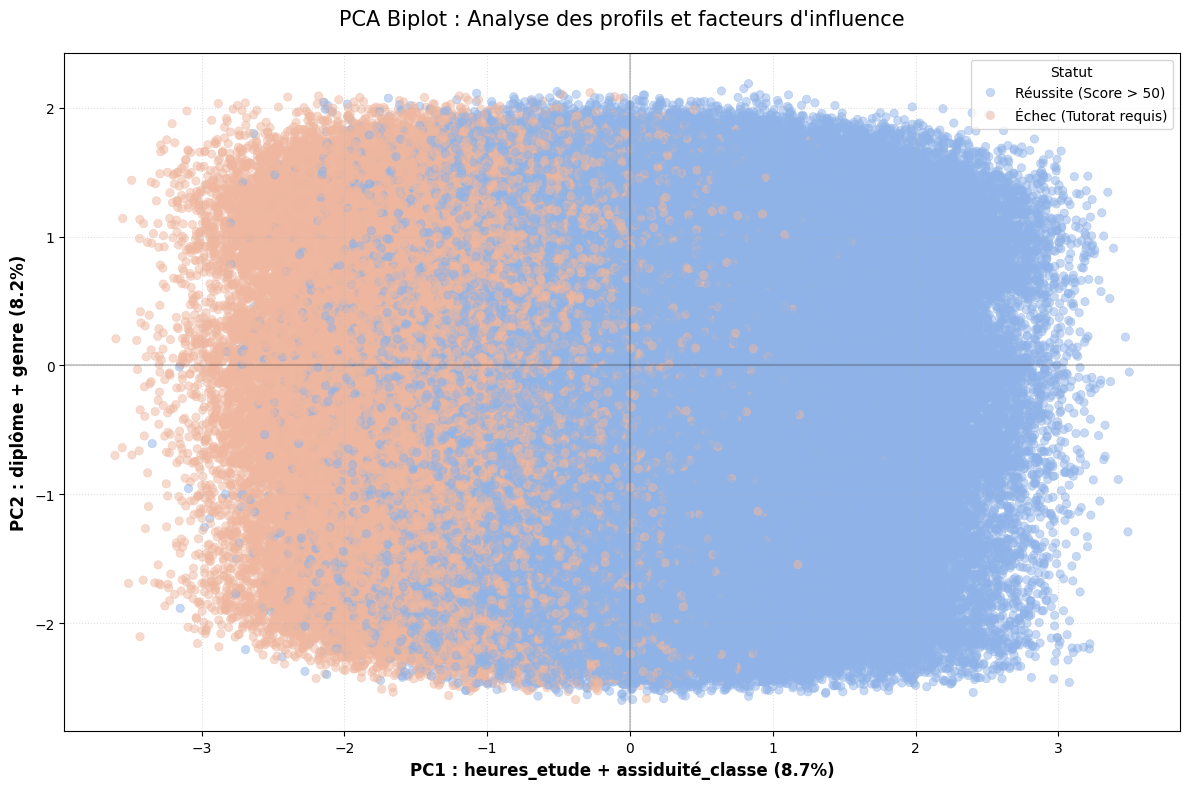

In [32]:
pca_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2))
])

X_pca = pca_pipeline.fit(X_mi).transform(X_mi)
pca_model = pca_pipeline.named_steps['pca']
feature_names = X_mi.columns

loadings = pd.DataFrame(
    pca_model.components_.T,
    columns=['PC1', 'PC2'],
    index=feature_names
)

def get_axis_description(pc_name, top_n=2):
    top_features = loadings[pc_name].abs().sort_values(ascending=False).head(top_n).index.tolist()
    return " + ".join(top_features)

# Définition des labels dynamiques basés sur les données réelles
label_pc1 = f"PC1 : {get_axis_description('PC1')} ({pca_model.explained_variance_ratio_[0]*100:.1f}%)"
label_pc2 = f"PC2 : {get_axis_description('PC2')} ({pca_model.explained_variance_ratio_[1]*100:.1f}%)"

# Statut explicite pour aligner la légende et les couleurs
status = (y_train < 50).map({
    False: "Réussite (Score > 50)",
    True: "Échec (Tutorat requis)"
})
status_palette = {
    "Réussite (Score > 50)": "#8fb3e8",
    "Échec (Tutorat requis)": "#efb79f"
}

# 3. Visualisation Professionnelle
plt.figure(figsize=(12, 8))

# Scatter plot avec transparence (alpha) pour gérer la superposition
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=status,
    hue_order=["Réussite (Score > 50)", "Échec (Tutorat requis)"],
    palette=status_palette,
    alpha=0.5,
    edgecolor=None
)



# Cosmétique et structure du rapport [cite: 45]
plt.axvline(0, color='black', linestyle='-', alpha=0.2)
plt.axhline(0, color='black', linestyle='-', alpha=0.2)
plt.title("PCA Biplot : Analyse des profils et facteurs d'influence", fontsize=15, pad=20)
plt.xlabel(label_pc1, fontsize=12, fontweight='bold')
plt.ylabel(label_pc2, fontsize=12, fontweight='bold')
plt.legend(title="Statut", loc='upper right')
plt.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()